# psnow file


In [2]:
import datetime
import os
import glob
import gc
import pandas as pd
import xarray as xr
import numpy as np
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors as mcolors
import cmcrameri.cm as ccm

from params import boundaries
from myutil import make_ts, rescale_lists
from dirs import workdir
plt.style.use('science.mplstyle')
projectdir = '/glade/campaign/uwyo/wyom0200/berkeley/'

In [3]:
domains = ['d01', 'd02']
coordsdict = {}
for domain in domains:
    coordsdict[domain] = xr.open_dataset(f'{workdir}wrfinput_{domain}')

In [4]:
params = {'vars': ['prec','t2','snow'],
          'states' : ['CA', 'WY'],
          'res': ['45','9','3']}
res_domain = {'3': ['d03','d04'],
               '9' :['d02'],
               '45':['d01']}
domain_state = {'d01':['CA','WY'],
                'd02':['CA','WY'],
                'd03':['CA'],
                'd04':['WY'],}
boundaries = {'d01':{'CA': [43,60,35,68], ## left, right, bottom, top
                     'WY': [68,81,43,63]},
              'd02':{'CA': [44,125,87,251],
                     'WY': [165,230,130,227]},
              'd03':{'CA': [0,-1,0,-1]},
              'd04':{'WY': [0,-1,0,-1]}}
state_res_domain = {'CA': {'45':'d01', '9': 'd02', '3':'d03'},
                    'WY': {'45':'d01', '9': 'd02', '3':'d04'},}

gcms_dict = {'d01': ['cesm2','mpi-esm1-2-lr','cnrm-esm2-1',
                     'ec-earth3-veg','fgoals-g3','ukesm1-0-ll',
                     'canesm5','access-cm2','ec-earth3'],
             'd02': ['cesm2','mpi-esm1-2-lr','cnrm-esm2-1',
                     'ec-earth3-veg','fgoals-g3','ukesm1-0-ll',
                     'canesm5','access-cm2','ec-earth3'],}
bc = 'BC'

In [5]:
mygcms = ['cesm2','mpi-esm1-2-lr','cnrm-esm2-1','ec-earth3-veg',
          'fgoals-g3','canesm5','access-cm2','ec-earth3']

partitions = []
for gcm in mygcms:
    partition = np.load(f'{projectdir}partition_annual_{gcm}.npy',
                        allow_pickle=True).flatten()[0]
    partitions.append(partition)

snowmasks = np.load('/glade/work/mcowherd/snowmasks.npy', allow_pickle=True).flatten()[0]

8 GCMs loaded: ['cesm2', 'mpi-esm1-2-lr', 'cnrm-esm2-1', 'ec-earth3-veg', 'fgoals-g3', 'canesm5', 'access-cm2', 'ec-earth3']


In [6]:
## windows
BASE_Y = (1981, 2009)
EOC_Y  = (2070, 2099)

def series_for(partition, state, res, ptype):
    """Domain-mean annual Nov-Apr volume [mm], one value per year."""
    domain = state_res_domain[state][res]
    mask   = snowmasks[state][res]
    left, right, bottom, top = boundaries[domain][state]
    tmp = partition[state][res][ptype].sel(lat2d=slice(bottom, top),
                                           lon2d=slice(left, right))['prec']
    return np.nanmean(tmp.where(mask), axis=(1, 2))[1:-2]

_probe = series_for(partitions[0], 'CA', '9', 'snowfall')
YEARS = np.arange(1981, 1981 + len(_probe))
BASE  = (YEARS >= BASE_Y[0]) & (YEARS <= BASE_Y[1])
EOC   = (YEARS >= EOC_Y[0])  & (YEARS <= EOC_Y[1])

print(f'series length {len(_probe)} -> years {YEARS[0]}-{YEARS[-1]}')
print(f'baseline {YEARS[BASE][0]}-{YEARS[BASE][-1]} ({BASE.sum()} yr)')
print(f'eoc      {YEARS[EOC][0]}-{YEARS[EOC][-1]} ({EOC.sum()} yr)')

series length 118 -> years 1981-2098
baseline 1981-2009 (29 yr)
eoc      2070-2098 (29 yr)
NOTE: archive ends 2098, so the end-of-century window is 2070-2098, not 2070-2099. Say so in the text or confirm 2099 exists in the source files.


In [7]:
## ============ NUMBERS FOR THE MANUSCRIPT ============
region_name = {'CA': 'Sierra Nevada', 'WY': 'Middle Rockies'}

vol = {}                       # vol[state][res][ptype] = (baseline per GCM, eoc per GCM)
for state in params['states']:
    vol[state] = {}
    for res in ['45', '9']:
        vol[state][res] = {}
        for ptype in ['snowfall', 'rainfall']:
            b, e = [], []
            for k, gcm in enumerate(mygcms):
                d = series_for(partitions[k], state, res, ptype)
                b.append(np.nanmean(d[BASE]))
                e.append(np.nanmean(d[EOC]))
            vol[state][res][ptype] = (np.array(b), np.array(e))

print('=' * 88)
print('SECTION 3.1 -- Figure 6 paragraph')
print('=' * 88)
for state in params['states']:
    for ptype in ['snowfall', 'rainfall']:
        verb = 'decreases' if ptype == 'snowfall' else 'increases'
        parts = []
        for res in ['9', '45']:
            b, e = vol[state][res][ptype]
            pct = 100 * (e - b) / b
            parts.append(f'{res:>2s} km {abs(pct.mean()):5.1f} +/- {pct.std():4.1f} % '
                         f'({abs((e - b).mean()):4.0f} +/- {(e - b).std():3.0f} mm)')
        print(f'{region_name[state]:15s} {ptype:9s} {verb:9s} by   ' + '   |   '.join(parts))
print()

print('-' * 88)
print('baseline volumes [mm] -- these are what the percentages divide by')
print('-' * 88)
for state in params['states']:
    for res in ['9', '45']:
        sb = vol[state][res]['snowfall'][0].mean()
        rb = vol[state][res]['rainfall'][0].mean()
        print(f'{region_name[state]:15s} {res:>2s} km   snowfall {sb:7.1f}   '
              f'rainfall {rb:7.1f}   snow fraction {sb / (sb + rb):.3f}')
print()

print('-' * 88)
print('snowfall:rainfall ratio, 9 km  (text: 0.23+/-0.06 SN, 0.37+/-0.05 MR;')
print('                                baseline 0.47+/-0.05 SN, 0.48+/-0.02 MR)')
print('-' * 88)
for state in params['states']:
    sb, se = vol[state]['9']['snowfall']
    rb, re_ = vol[state]['9']['rainfall']
    fb, fe = sb / (sb + rb), se / (se + re_)
    print(f'{region_name[state]:15s} baseline {fb.mean():.2f} +/- {fb.std():.2f}   '
          f'-> end-of-century {fe.mean():.2f} +/- {fe.std():.2f}')
print()

print('-' * 88)
print('total precipitation direction, 9 km  (text: 3 up / 5 down SN, 4 / 4 MR)')
print('-' * 88)
for state in params['states']:
    sb, se = vol[state]['9']['snowfall']
    rb, re_ = vol[state]['9']['rainfall']
    dp = (se + re_) - (sb + rb)
    print(f'{region_name[state]:15s} {int((dp > 0).sum())} increase, {int((dp < 0).sum())} decrease')
print()

print('-' * 88)
print('CONSISTENCY CHECK -- mm and % now share a baseline, so these must agree')
print('-' * 88)
for state in params['states']:
    for res in ['9', '45']:
        for ptype in ['snowfall', 'rainfall']:
            b, e = vol[state][res][ptype]
            per_gcm  = (100 * (e - b) / b).mean()      # reported: spread is across GCMs
            of_means = 100 * (e - b).mean() / b.mean()
            flag = '' if abs(per_gcm - of_means) < 1.0 else '   <-- inter-model spread is large here'
            print(f'{region_name[state]:15s} {res:>2s} km {ptype:9s} '
                  f'mean-of-ratios {per_gcm:+7.1f} %   ratio-of-means {of_means:+7.1f} %{flag}')
print()
print('Report the mean-of-ratios values, since the +/- in the text is the spread across models.')

SECTION 3.1 -- Figure 6 paragraph
Sierra Nevada   snowfall  decreases by    9 km  56.2 +/-  7.9 % ( 126 +/-  13 mm)   |   45 km  70.5 +/-  7.7 % (  78 +/-   9 mm)
Sierra Nevada   rainfall  increases by    9 km  23.1 +/- 13.4 % ( 131 +/-  82 mm)   |   45 km  18.2 +/- 11.3 % (  90 +/-  56 mm)
Middle Rockies  snowfall  decreases by    9 km  30.0 +/-  7.1 % (  68 +/-  15 mm)   |   45 km  36.4 +/-  6.4 % (  68 +/-   8 mm)
Middle Rockies  rainfall  increases by    9 km  30.4 +/- 12.5 % (  80 +/-  37 mm)   |   45 km  31.3 +/- 15.9 % (  71 +/-  36 mm)

----------------------------------------------------------------------------------------
baseline volumes [mm] -- these are what the percentages divide by
----------------------------------------------------------------------------------------
Sierra Nevada    9 km   snowfall   226.0   rainfall   559.7   snow fraction 0.288
Sierra Nevada   45 km   snowfall   111.4   rainfall   499.5   snow fraction 0.182
Middle Rockies   9 km   snowfall   229.5 

/glade/derecho/scratch/mcowherd/tmp/ipykernel_30431/297155553.py:21: RuntimeWarning: Mean of empty slice
  m, s = np.nanmean(roll, axis=0), np.nanstd(roll, axis=0)
/glade/u/home/mcowherd/.conda/envs/fos/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


OSError: [Errno 122] Disk quota exceeded

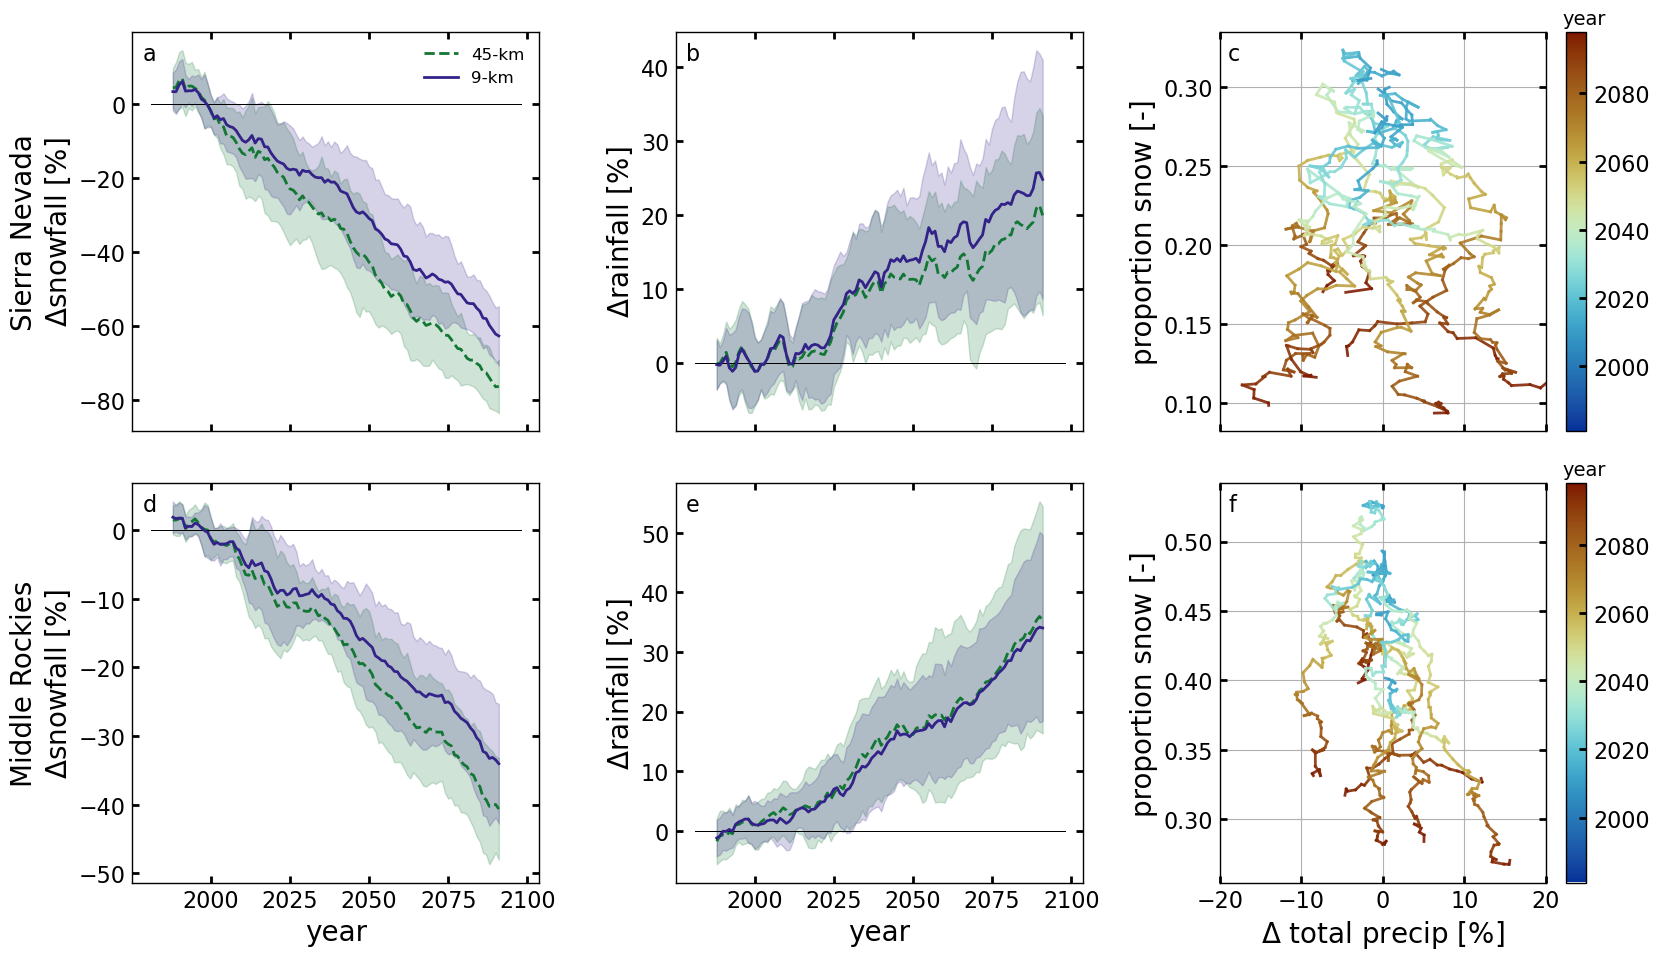

In [8]:
ws = 15
resstyles = {'45': '--', '9': '-'}
fig, axs = plt.subplots(2, 3, figsize=(17, 10))

for i, state in enumerate(params['states']):
    for res in ['45', '9']:
        line_color = '#332288' if res == '9' else '#117733'
        for j, ptype in enumerate(['snowfall', 'rainfall']):
            ax = axs[i, j]
            ax.plot([YEARS[0], YEARS[-1]], [0, 0], 'black', linewidth=0.7)

            curves = []
            for k, gcm in enumerate(mygcms):
                d = series_for(partitions[k], state, res, ptype)
                base = np.nanmean(d[BASE])              # 1981-2009, raw annual
                curves.append(100 * (d - base) / base)

            roll = pd.DataFrame(np.array(curves).T).rolling(ws, min_periods=ws).mean().values.T
            ry   = pd.Series(YEARS).rolling(ws, min_periods=ws).mean().values
            m, s = np.nanmean(roll, axis=0), np.nanstd(roll, axis=0)
            ok = ~np.isnan(m) & ~np.isnan(ry)

            ax.fill_between(ry[ok], (m - s)[ok], (m + s)[ok], alpha=0.2, color=line_color)
            ax.plot(ry[ok], m[ok], linestyle=resstyles[res], color=line_color,
                    linewidth=2, label=f'{res}-km')

            ax.set_ylabel(r'$\Delta$' + f'{ptype}' + r' [%]')
            if i == 0: ax.set_xticklabels([])
            if j == 0: ax.set_ylabel(f'{region_name[state]}\n' + r'$\Delta $' + f'{ptype}' + r' [%]')
            if i == 1: ax.set_xlabel('year')

    # third column: snow proportion against total precipitation change, 9 km
    ax = axs[i, 2]
    ws2, cmap = 30, ccm.roma_r
    for k, gcm in enumerate(mygcms):
        snow = series_for(partitions[k], state, '9', 'snowfall')
        rain = series_for(partitions[k], state, '9', 'rainfall')
        pbase = np.nanmean((snow + rain)[BASE])         # same 1981-2009 window
        rollsnow = pd.Series(snow).rolling(ws2, min_periods=ws2).mean().values
        rollrain = pd.Series(rain).rolling(ws2, min_periods=ws2).mean().values
        rollprec = rollsnow + rollrain
        x = 100 * (rollprec - pbase) / pbase
        y = rollsnow / rollprec
        c = np.linspace(0, 1, len(YEARS))
        for idx in range(len(x) - 1):
            ax.plot(x[idx:idx + 2], y[idx:idx + 2], color=cmap(c[idx]), linewidth=2, alpha=0.9)

    ax.set_ylabel('proportion snow [-]')
    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=mcolors.Normalize(vmin=YEARS[0], vmax=YEARS[-1]))
    plt.colorbar(sm, ax=ax)
    ax.text(1.05, 1.02, 'year', rotation=0, transform=ax.transAxes, fontsize=14)
    ax.grid(True)
    ax.set_xlim((-20, 20))

h, l = axs[0, 0].get_legend_handles_labels()
axs[0, 0].legend(h, l, loc='upper right', fontsize=12)
axs[0, 2].set_xticklabels([])
axs[1, 2].set_xlabel(r'$\Delta$ total precip [%]')
plt.tight_layout()
for i, ax in enumerate(axs.flatten()):
    ax.text(0.025, 0.93, chr(97 + i), transform=ax.transAxes, fontsize=16)

plt.savefig('../figures/fig_psnow_simple_relative.jpg', dpi=400)
plt.show()